In [27]:
import numpy as np
import pickle
import pandas as pd
import yaml
import os
from matplotlib import pyplot as plt

In [28]:
from hsa_hopper.collocation import interp_covector, diff_tensor

def smooth_dynamics(df):
    degree = 5
    window = 20
    x = df['x_rad'].to_numpy()
    tau = df['torque'].to_numpy()
    t = df['t_s'].to_numpy(copy=True)
    t = t-t[0]
    x_filt = np.zeros_like(x)
    xdot = np.zeros_like(x)
    xddot = np.zeros_like(x)
    tau_filt = np.zeros_like(x)
    for i in range(window//2, t.size-window//2):

        if i-window//2 < 0:
            start_idx = 0
            stop_idx = window
        elif i+window//2 >= t.size:
            start_idx = t.size-window//2-1
            stop_idx = t.size
        else:
            start_idx = i-window//2
            stop_idx = start_idx + window

        stop_idx = min(t.size,start_idx+window)
        A = np.vstack([
            interp_covector(t[j],t[start_idx],t[stop_idx-1],degree+1)
                for j in range(start_idx,stop_idx)
        ])
        x_coeffs, res, rank, s = np.linalg.lstsq(A,x[start_idx:stop_idx],rcond=None)
        dt = diff_tensor(t[start_idx],t[stop_idx-1],degree+1)
        t_eval = interp_covector(t[i], t[start_idx], t[stop_idx-1], degree+1)

        x_filt[i] = np.dot(t_eval, x_coeffs)[0]
        xdot_coeffs = dt@x_coeffs
        xdot[i] = np.dot(t_eval, xdot_coeffs)[0]
        xddot[i] = np.dot(t_eval, dt@xdot_coeffs)[0]

        tau_coeffs, res, rank, s = np.linalg.lstsq(A,tau[start_idx:stop_idx],rcond=None)
        tau_filt[i] = np.dot(t_eval, tau_coeffs)[0]

    df['x_rad'] = x_filt
    df['xdot'] = xdot
    df['xddot'] = xddot
    df['torque'] = tau_filt
    return df

In [29]:
from hsa_hopper.kinematics import KinematicParameters, forward_kinematics

def compute_kinematics(df: pd.DataFrame, params: KinematicParameters):
    x = df['x_rad'].to_numpy()
    xdot = df['xdot'].to_numpy()
    xddot = df['xddot'].to_numpy()

    fk, jac, hess = forward_kinematics(params, x, jacobian=True, hessian=True)
    y = fk[0]
    l = fk[1]

    dydx = jac[0]    
    ydot = jac[0]*xdot

    d2yd2x = hess[0]
    yddot = dydx*xddot + xdot*d2yd2x*xdot

    dldx = jac[1]
    ldot = dldx*xdot

    d2ld2x = hess[1]
    lddot = dldx*xddot + xdot*d2ld2x*xdot

    df['y_m'] = y
    df['l_m'] = l
    df['dydx'] = dydx
    df['ydot'] = ydot
    df['dldx'] = dldx
    df['ldot'] = ldot
    df['d2yd2x'] = d2yd2x
    df['yddot'] = yddot
    df['d2ld2x'] = d2yd2x
    df['lddot'] = lddot

    return df

In [30]:
"""
Load all data from the HSA characterization dataset
"""
experiment_folder = r'/home/joseph/workspaces/hsa_hopper/hsa_hopper_control/data/hsa_identification/2025-04-10_1744325155'

with open(os.path.join(experiment_folder, 'experiment_config.yaml'), 'r') as f:
    experiment_config = yaml.load(f, yaml.Loader)

with open(os.path.join(experiment_folder, 'hardware_config.yaml'), 'r') as f:
    hardware_config = yaml.load(f, yaml.Loader)

from hsa_hopper.kinematics import KinematicParameters
kin_params = KinematicParameters(
    hardware_config['kinematics']['a'],
    hardware_config['kinematics']['b'],
    hardware_config['kinematics']['c'],
    hardware_config['kinematics']['d'],
)

actuator_model_path = r'/home/joseph/workspaces/hsa_hopper/hsa_hopper_control/notebooks/no_hsa_model.yaml'
with open(actuator_model_path, 'r') as f:
    actuator_model = yaml.load(f, yaml.Loader)

data_files = []
twist_angles = []
for path in os.listdir(experiment_folder):
    if '.csv' in path:
        twist_angle = float(path.split('_')[0])*np.pi/180
        twist_angles.append(twist_angle)
        data_files.append(os.path.join(experiment_folder,path))

dataframes = []
for i, path in enumerate(data_files):
    df = pd.read_csv(path)
    df['psi'] = twist_angles[i]*np.ones(len(df))
    dataframes.append(smooth_dynamics(df))

df = pd.concat(dataframes)
compute_kinematics(df, kin_params)
print(len(df))

25709


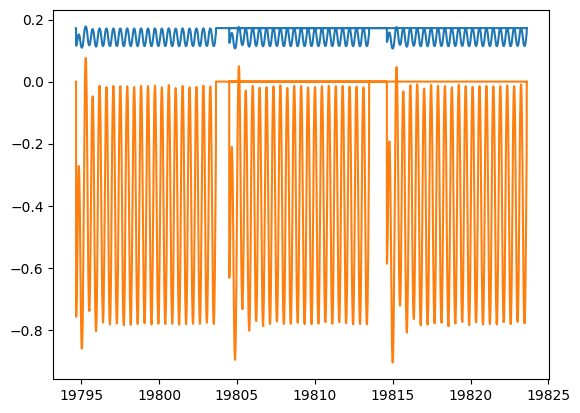

In [31]:
from matplotlib import pyplot as plt
# plt.plot(df['t_s'], df['xdot'])
t = df['t_s'].to_numpy()
t = t - t[0]
x = df['x_rad'].to_numpy()
xdot = df['xdot'].to_numpy()
# plt.plot(t,xdot)
# plt.plot(t[:-1], np.diff(x)/np.diff(t))
plt.plot(df['t_s'], df['l_m'])
plt.plot(df['t_s'], df['x_rad'])


In [32]:
from numpy.random import default_rng

N_ROWS = len(df)
rng = default_rng(seed=42)
TRAIN_INDICES = rng.choice(N_ROWS, 3*N_ROWS//10, replace=False)

In [33]:
from hsa_hopper.hsa_model import HSAModel
def make_lstsq_data(hsa_model: HSAModel, actuator_model: dict, row_indices):
    DATA_COLUMN_MAP = {key : i for i, key in enumerate(df.columns)}
    M = len(row_indices)
    A = np.zeros((M,3+hsa_model.num_params()))
    b = np.zeros(M)
    for i, idx in enumerate(row_indices):
        l = df.iloc[idx,DATA_COLUMN_MAP['l_m']]
        psi = df.iloc[idx,DATA_COLUMN_MAP['psi']]
        xdot = df.iloc[idx,DATA_COLUMN_MAP['xdot']]
        ldot = df.iloc[idx,DATA_COLUMN_MAP['ldot']]
        xddot = df.iloc[idx,DATA_COLUMN_MAP['xddot']]
        lddot = df.iloc[idx,DATA_COLUMN_MAP['lddot']]
        tau = df.iloc[idx,DATA_COLUMN_MAP['torque']]
        dldx = df.iloc[idx,DATA_COLUMN_MAP['dldx']]
        d2ld2x = df.iloc[idx,DATA_COLUMN_MAP['d2ld2x']]
        b[i] = tau
        b[i] -= actuator_model['J']*xddot
        b[i] -= actuator_model['bx']*xdot
        b[i] -= actuator_model['bl']*dldx*ldot
        b[i] -= actuator_model['m_foot']*(lddot+9.81)*dldx
        A[i,0] = xddot                      # column 0 -> motor inertia
        A[i,1] = xdot                       # column 1 -> motor damping
        A[i,2] = (lddot+9.81)*dldx          # column 2 -> leg inertia
        A[i,3] = dldx*l                 # column 4 -> leg linear spring force
        A[i,4] = dldx                   # column 5 -> leg linear spring preload
        A[i,5] = dldx*ldot              # column 5 -> leg linear damping 
    return A,b

In [34]:
"""
Experimental - fitting two potential functions and blending them together with a logistic function
"""

from scipy.optimize import minimize
from scipy.optimize import LinearConstraint
from hsa_hopper.hsa_model import HSAModel

# function to do the model optimization
def governing_equation_lstsq(hsa_model: HSAModel, actuator_model: dict):
    # N = model.num_params()
    A,b = make_lstsq_data(hsa_model, actuator_model, TRAIN_INDICES)

    # rescaling A matrix for better conditioning of constraint evaluation
    SCALE = np.ones(A.shape[1])
    SCALE[0] = 1/1000   # motor inertia rescaling
    SCALE[1] = 1/1000   # motor damping rescaling
    SCALE[2] = 1/100    # leg inertia rescaling
    SCALE[3] = 100      # leg linear spring constant rescaling
    SCALE[4] = 100      # leg spring preload rescaling
    SCALE[5] = 1        # leg damping rescaling

    A_scaled = A*SCALE
    ATA = A_scaled.T@A_scaled
    ATb = A_scaled.T@b
    bTb = np.dot(b,b)
    f = lambda x: x.T@ATA@x+bTb-2*x.T@ATb
    jac = lambda x: 2*ATA@x-2*ATb

    # rescaling matrix for parameters, useful for conditioning
    # the constraint evaluations

    # next constraints - enforce positive weights
    # and positive definiteness of stiffness/damping at basis centers
    C = np.eye(A.shape[1])
    lb = np.zeros(A.shape[1])
    lb[0] = 3
    lb[1] = -1e-3
    lb[2] = 0
    lb[3] = 0
    lb[4] = -1e3
    lb[5] = -1e-3
    ub = np.zeros(A.shape[1])
    ub[0] = 5
    ub[1] = 1.
    ub[2] = 50.
    ub[3] = 1e3
    ub[4] = 1e3
    ub[5] = 1e3
    constraints = [LinearConstraint(C,lb=lb,ub=ub)]

    x0 = np.zeros(A.shape[1])
    result = minimize(f, x0, 
                    jac=jac, 
                    constraints=constraints, 
                    method='SLSQP',
                    options={'maxiter' : 12000}
    )
    result.A = A
    result.b = b
    result.sample_size = b.shape[0]
    result.model = hsa_model
    result.num_params = hsa_model.num_params()
    result.J_x = result.x[0]*SCALE[0]
    result.b_x = result.x[1]*SCALE[1]
    result.m_foot = result.x[2]*SCALE[2]
    result.model.K = result.x[3]*SCALE[3]
    result.model.F0 = result.x[4]*SCALE[4]
    result.model.b = result.x[5]*SCALE[5]
    result.r_sqr = 1-result.fun/np.sum((b-np.average(b))**2)
    result.r_sqr_adj = 1-(1-result.r_sqr)*(result.sample_size-1)/(result.sample_size-result.num_params-1)
    result.mse = result.fun/result.sample_size
    result.rmse = np.sqrt(result.mse)
    result.bic = result.sample_size*np.log(result.mse)+result.num_params*np.log(result.sample_size)
    result.errors = A@(SCALE*result.x)-b
    return result 
    

In [35]:
y_basis = np.zeros((0,2))
w_c = np.zeros(y_basis.shape[1])
w_d = np.zeros(y_basis.shape[1])
hsa_model = HSAModel(0,0,0,y_basis,w_c,w_d,np.sqrt(2),np.sqrt(2),kind=HSAModel.LINEAR)

# choosing an optimal (s) for a linear damping model according to the number of basis functions
result = governing_equation_lstsq(hsa_model, actuator_model)
print(result)
# import yaml
# with open('no_hsa_model.yaml', 'w') as f:
#     yaml.dump({
#         'J' : float(result.J_x),
#         'm_foot' : float(result.m_foot),
#         'bx' : float(result.b_x),
#         'bl' : float(result.b_leg)
#     }, f, yaml.Dumper)
print(hsa_model.K)
print(hsa_model.F0)
print(hsa_model.b)

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 1055.1605283336612
           x: [ 3.000e+00  1.000e+00  1.066e-10  8.420e+00 -1.113e+00
                1.070e+01]
         nit: 10
         jac: [ 3.318e+02 -2.224e-01  1.766e+01 -1.061e-02 -5.292e-02
               -2.544e-04]
        nfev: 17
        njev: 10
           A: [[ 1.508e+01  6.655e+00 ...  7.675e-02  3.920e-02]
               [ 2.837e+02 -5.917e+00 ...  7.606e-02 -3.423e-02]
               ...
               [-6.283e+01 -6.031e+00 ...  7.719e-02 -3.594e-02]
               [-9.442e+01 -1.926e+00 ...  7.149e-02 -9.843e-03]]
           b: [ 5.270e-01 -2.385e-01 ...  5.808e-01  2.033e+00]
 sample_size: 7712
       model: <hsa_hopper.hsa_model.HSAModel object at 0x76c6bbd8e490>
  num_params: 3
         J_x: 0.0030000000017196982
         b_x: 0.0009999999991250625
      m_foot: 1.065703408818411e-12
       r_sqr: 0.8947227170942492
   r_sqr_adj: 0.8946817425420026
         mse

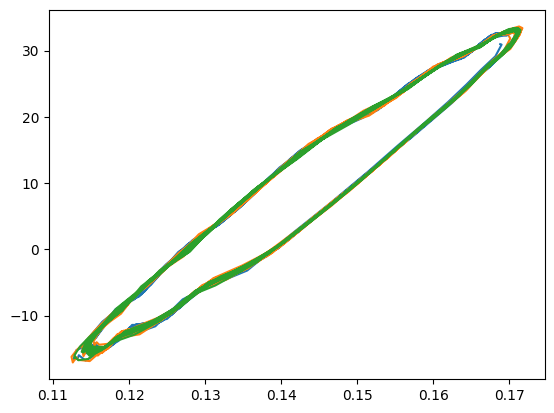

In [36]:
fig, axs = plt.subplots()
for psi in twist_angles:
    frame = df['psi'] == psi
    l = df.loc[frame, 'l_m'].to_numpy()[1000:-1000:10]
    ldot = df.loc[frame, 'ldot'].to_numpy()[1000:-1000:10]

    z = np.zeros((l.size, 2))
    z[:,0] = l
    z[:,1] = psi
    zdot = np.zeros((ldot.size,2))
    zdot[:,0] = ldot

    # spring_force = np.array([hsa_model.K*l+hsa_model.F0 for i in range(z.shape[0])])
    spring_force = hsa_model.K*l+hsa_model.F0
    damp_force = hsa_model.b*ldot 
    plt.plot(z[:,0], spring_force+damp_force)